In [1]:
import numpy as np
import matplotlib.pyplot as plt
import specula
specula.init(-1)  # CPU execution
from specula.data_objects.iir_filter_data import IirFilterData

Cupy import successfull. Installed version is: 13.6.0
Default device is CPU


In [2]:

# --- Configuration ---
fs = 2000.0         # Sampling frequency [Hz]
gain = 0.7         # Loop gain
ff = 0.995          # Forgetting factor (leaky integrator)
delay_frames = 2.0  # Total loop delay [frames]
fc_lpf = 400.0      # Mirror LPF cutoff [Hz]

# 1. Define Controller (C)
controller = IirFilterData.from_gain_and_ff(gain=[gain], ff=[ff])

# 2. Define Plant Components (P)
# Delay TF: interpolates between samples for fractional values
nw_delay, dw_delay = controller.discrete_delay_tf(delay_frames)

# Mirror dynamics (2nd order Butterworth)
lpf_obj = IirFilterData.lpf_from_fc(fc=fc_lpf, fs=fs, n_ord=4)
lpf_num, lpf_den = lpf_obj.num[0], lpf_obj.den[0]

# 3. Assemble the Open Loop (CP)
# Open Loop Numerator = C_num * P_delay_num * LPF_num
nw_plant = np.convolve(nw_delay, lpf_num)
dm_plant = np.convolve(dw_delay, lpf_den)

# --- Performance Plotting ---
freq = np.logspace(-2, np.log10(fs/2), 4000)
rtf_mag = controller.RTF(mode=0, fs=fs, freq=freq, dm=dm_plant, nw=nw_plant, dw=1.0, plot=False)
ntf_mag = controller.NTF(mode=0, fs=fs, freq=freq, dm=dm_plant, nw=nw_plant, dw=1.0, plot=False)
rtf_mag_nodm = controller.RTF(mode=0, fs=fs, freq=freq, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)
ntf_mag_nodm = controller.NTF(mode=0, fs=fs, freq=freq, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)

Text(0.5, 1.0, 'DM step response\n($f_{cut}$ = 400.0 Hz)')

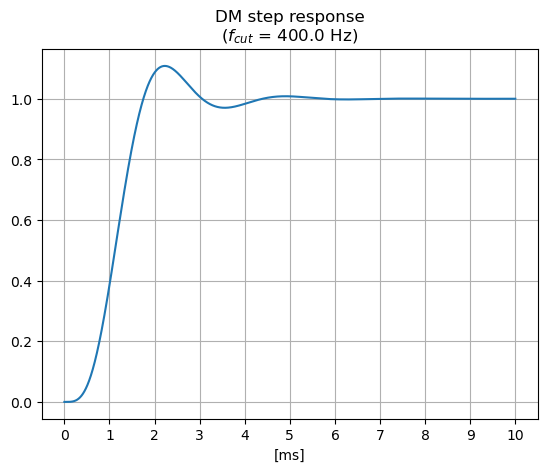

In [3]:
dt = 1e-6
T = np.arange(0, 0.01/dt) * dt
dm_obj = IirFilterData.lpf_from_fc(fc=fc_lpf, fs=1/dt, n_ord=4)
tvec,step=dm_obj.step_response(dt=dt,T=T)

plt.figure()
plt.plot(tvec*1e+3,step)
plt.xlabel('[ms]')
plt.xticks(np.arange(0,11))
plt.grid()
plt.title('DM step response\n'+r'($f_{cut}$ = '+f'{fc_lpf} Hz)')

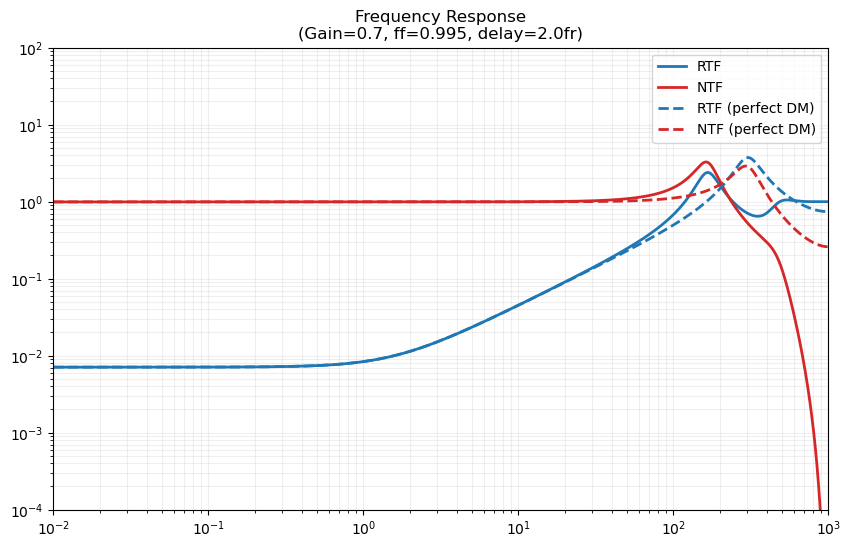

In [4]:
plt.figure(figsize=(10, 6))
plt.loglog(freq, rtf_mag, label='RTF', linewidth=2, c='C0')
plt.loglog(freq, ntf_mag, label='NTF', linewidth=2, c='C3')
plt.loglog(freq, rtf_mag_nodm,'--', label='RTF (perfect DM)', linewidth=2, c='C0')
plt.loglog(freq, ntf_mag_nodm, '--', label='NTF (perfect DM)', linewidth=2, c='C3')
plt.title(f'Frequency Response\n(Gain={gain}, ff={ff}, delay={delay_frames}fr)')
plt.legend(loc='lower left')
plt.grid(True, which="both", alpha=0.2)
plt.legend()
plt.ylim([1e-4,100])
plt.xlim([1e-2,fs/2])

# --- Stability Analysis (Nyquist) ---
ol_num = np.convolve(controller.num[0], nw_plant)
ol_den = np.convolve(controller.den[0], dm_plant)

open_loop_obj = IirFilterData(ordnum=[len(ol_num)], ordden=[len(ol_den)], num=[ol_num], den=[ol_den])

# plt.figure(figsize=(6, 6))
# open_loop_obj.nyquist_plot(dt=1/fs, unit_circle=True)

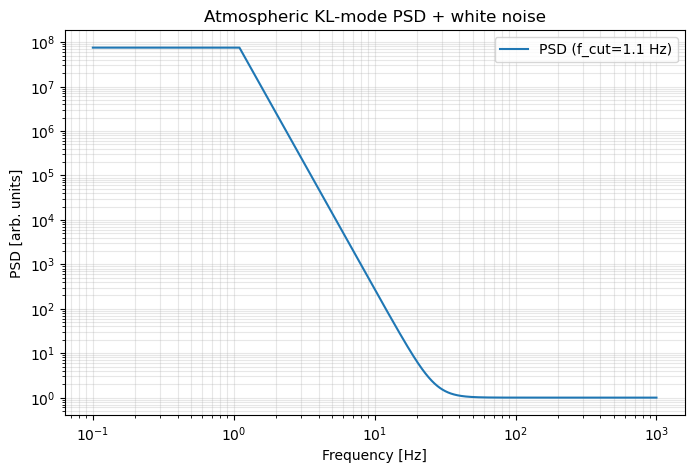

In [5]:
from scipy.integrate import simpson as simps

fs = 2000.0           # sampling frequency [Hz]
noise_floor = 1e-8    # white noise floor (m)
n = 2


def von_karman_power(k,r0,L0,D):
    C = 0.02289558710855519
    B = k**2 + (D/L0)**2
    return C * (r0/D)**(-5.0/3.0) * B**(-11.0/6.0)


def get_zernike_spectra(f, n:int, V:float, r0:float=10e-2, L0=25, D:float = 8.2, noise_floor:float=0.0):
    f_cut = 0.3 * (n+1) * V / D 
    psd = np.ones_like(f)
    if n == 1:
        psd[f<=f_cut] = (f[f<=f_cut] / f_cut) ** (-2.0/3.0)
    psd[f>f_cut] = (f[f>f_cut] / f_cut) ** (-17.0/3.0)
    vkp = von_karman_power(n/D, r0, L0, D) * (2*np.pi*500e-9)**2
    psd *= vkp/simps(psd,f)
    psd += noise_floor**2
    return psd, f_cut

freq_psd = np.logspace(-1, np.log10(fs/2), 2000)
psd, f_cut = get_zernike_spectra(freq_psd, n=n, V=10, noise_floor=noise_floor)
psd /= noise_floor**2

# plot results
plt.figure(figsize=(8,5))
plt.loglog(freq_psd, psd, label=f'PSD (f_cut={f_cut:.1f} Hz)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [arb. units]')
plt.title('Atmospheric KL-mode PSD + white noise')
plt.grid(which='both', alpha=0.3)
plt.legend()
plt.show()

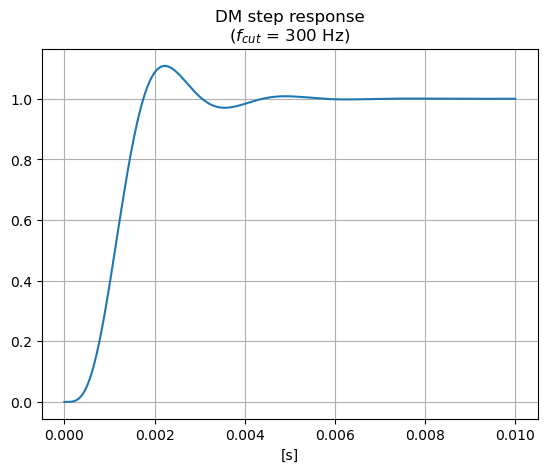

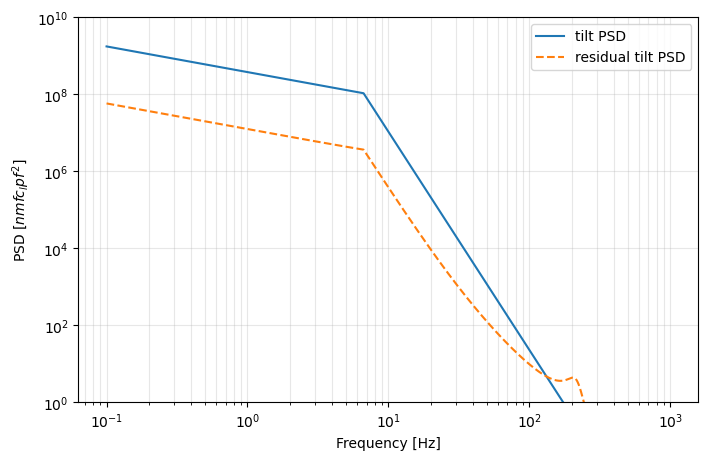

41.704891310783104 7.627837651806848


In [ ]:

psd_tt, f_cut = get_zernike_spectra(freq_psd, n=1, V=20, r0=3e-2, D=1.8)
psd_tt *= 1e+18

dt = 1e-3
T = np.arange(0, 10/dt) * dt
nw_delay, dw_delay = controller.discrete_delay_tf(2)

fc_lpf = 300
lpf_obj = IirFilterData.lpf_from_fc(fc=fc_lpf, fs=1/dt, n_ord=2)
lpf_num, lpf_den = lpf_obj.num[0], lpf_obj.den[0]
nw_ttplant = np.convolve(nw_delay, lpf_num)
dm_ttplant = np.convolve(dw_delay, lpf_den)

tvec,step=dm_obj.step_response(dt=dt,T=T)

plt.figure()
plt.plot(tvec*dt,step)
plt.xlabel('[s]')
plt.grid()
plt.title('DM step response\n'+r'($f_{cut}$ = '+f'{fc_lpf} Hz)')


controller = IirFilterData.from_gain_and_ff(gain=[0.9], ff=[0.8])
rtf_tt = controller.RTF(mode=0, fs=1/dt, freq=freq_psd, dm=dm_ttplant, nw=nw_ttplant, dw=1.0, plot=False)
# rtf_tt = controller.RTF(mode=0, fs=100, freq=freq_psd, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)
res_tt = psd_tt * rtf_tt**2

plt.figure(figsize=(8,5))
plt.loglog(freq_psd, psd_tt, label=f'tilt PSD')
plt.loglog(freq_psd, res_tt, '--', label=f'residual tilt PSD')
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'PSD $[nmfc_lpf^2]$')
plt.grid(which='both', alpha=0.3)
plt.ylim([1,1e+10])
plt.legend()
plt.show()

print(np.sqrt(simps(psd_tt,freq_psd))/1000,np.sqrt(simps(res_tt,freq_psd))/1000)

In [ ]:
# --- Direct optimization of IIR coefficients to match PSD without RLS ---
from scipy.optimize import minimize
from scipy.signal import tf2zpk

order = 3

def estimate_theta(psd, f_cut, theta_guess=None, order:int=3, gain:float=0.7):
    p = order+1  # denominator length
    q = order  # numerator length
    if theta_guess is None:
        b_init = np.zeros(p - 1)
        a_init = np.zeros(q)
        ff = 1 - 2*np.pi*f_cut/fs
        controller = IirFilterData.from_gain_and_ff(gain=[gain], ff=[ff])
        b_orig = controller.den[0]
        a_orig = controller.num[0]

        b_init[: min(len(b_orig), len(b_init))] = b_orig[: min(len(b_orig), len(b_init))]
        a_init[: min(len(a_orig), len(a_init))] = a_orig[: min(len(a_orig), len(a_init))]

        init_theta = np.concatenate([b_init, a_init])
    else:
        init_theta = np.zeros(order*2)
        init_theta[:min(order,len(theta_guess)//2)] = theta_guess[:min(order,len(theta_guess)//2)]
        init_theta[order:order+min(order,len(theta_guess)//2)] = theta_guess[min(order,len(theta_guess)//2):]

    def iir_cost(theta):
        b = theta[: p-1]
        a = theta[p-1 :]
        filt = IirFilterData(ordnum=[len(a)], ordden=[len(b)], num=[a], den=[b])
        rtf = filt.RTF(mode=0, fs=fs, freq=freq_psd, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)
        C = 1/rtf**2
        return np.sum((np.log10(C)-np.log10(psd)) ** 2)

    result = minimize(iir_cost, init_theta, method='Powell', options={'maxiter':1e+5, 'ftol':1e-15})

    theta_est = result.x
    print("estimated theta", theta_est)
    z,p,k = tf2zpk(theta_est[order :],theta_est[: order])
    print('zeros: ',z,', poles: ',p, ', gain: ',k)
    return init_theta, theta_est

estimated theta [-1.00000138  1.00000142  0.97095772  0.68934377]
zeros:  [-0.7099627] , poles:  [1.00000004] , gain:  -0.9709563858702622
estimated theta [-0.50132336  1.00214229 -0.50082108  0.23428608 -0.45522619  0.23393756]
zeros:  [0.97151777+0.23380682j 0.97151777-0.23380682j] , poles:  [0.9994969+0.00201293j 0.9994969-0.00201293j] , gain:  -0.46733526065600856
estimated theta [-0.63489203  1.00075999 -0.09591442 -0.26995755  1.17765348 -1.617173
 -0.09498228  0.55894964]
zeros:  [ 0.94768076+0.10440884j  0.94768076-0.10440884j -0.52214517+0.j        ] , poles:  [ 1.00051532+0.00204189j  1.00051532-0.00204189j -0.42476264+0.j        ] , gain:  -1.8548877930583527


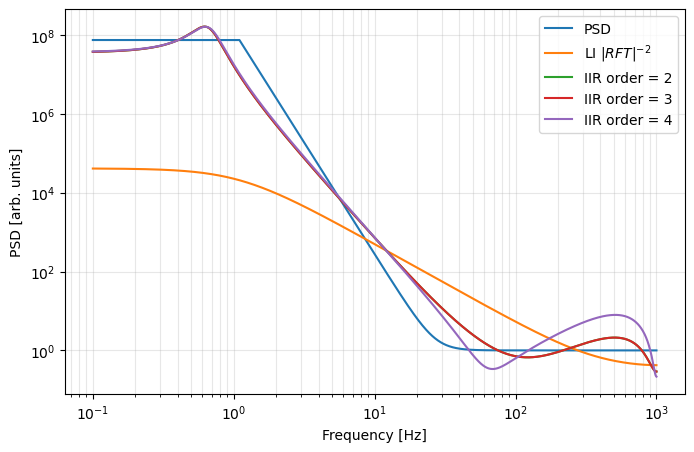

In [ ]:
order = 3

_, theta_est2 = estimate_theta(psd,f_cut,order=2)
_, theta_est = estimate_theta(psd,f_cut,order=3)
theta_init, theta_est4 = estimate_theta(psd,f_cut,order=4)

b_init = theta_init[: order]
a_init = theta_init[order :]
b_est2 = theta_est[: 2]
a_est2 = theta_est[2 :]
b_est = theta_est[: order]
a_est = theta_est[order :]
b_est4 = theta_est4[: 4]
a_est4 = theta_est4[4 :]

# compare on plot
filt_init = IirFilterData(ordnum=[len(a_init)], ordden=[len(b_init)], num=[a_init], den=[b_init])
C_init = filt_init.RTF(mode=0, fs=fs, freq=freq_psd, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)**-2 #np.abs(1 + filt_init.frequency_response(num=a_init, den=b_init, fs=fs, freq=freq_psd)) ** 2
filt_est = IirFilterData(ordnum=[len(a_est)], ordden=[len(b_est)], num=[a_est], den=[b_est])
C_est = filt_est.RTF(mode=0, fs=fs, freq=freq_psd, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)**-2 #np.abs(1 + filt_est.frequency_response(num=a_est, den=b_est, fs=fs, freq=freq_psd)) ** 2
filt_est2 = IirFilterData(ordnum=[len(a_est2)], ordden=[len(b_est2)], num=[a_est2], den=[b_est2])
C_est2 = filt_est.RTF(mode=0, fs=fs, freq=freq_psd, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)**-2 #np.abs(1 + filt_est.frequency_response(num=a_est, den=b_est, fs=fs, freq=freq_psd)) ** 2
filt_est4 = IirFilterData(ordnum=[len(a_est4)], ordden=[len(b_est4)], num=[a_est4], den=[b_est4])
C_est4 = filt_est4.RTF(mode=0, fs=fs, freq=freq_psd, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)**-2 #np.abs(1 + filt_est.frequency_response(num=a_est, den=b_est, fs=fs, freq=freq_psd)) ** 2

plt.figure(figsize=(8,5))
plt.loglog(freq_psd, psd, label=f'PSD')
plt.loglog(freq_psd, C_init, label=r'LI $|RFT|^{-2}$')
plt.loglog(freq_psd, C_est2, label=r'IIR order = 2')
plt.loglog(freq_psd, C_est, label=r'IIR order = 3')
plt.loglog(freq_psd, C_est4, label=r'IIR order = 4')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [arb. units]')
plt.grid(which='both', alpha=0.3)
plt.legend()

4.974644527595507


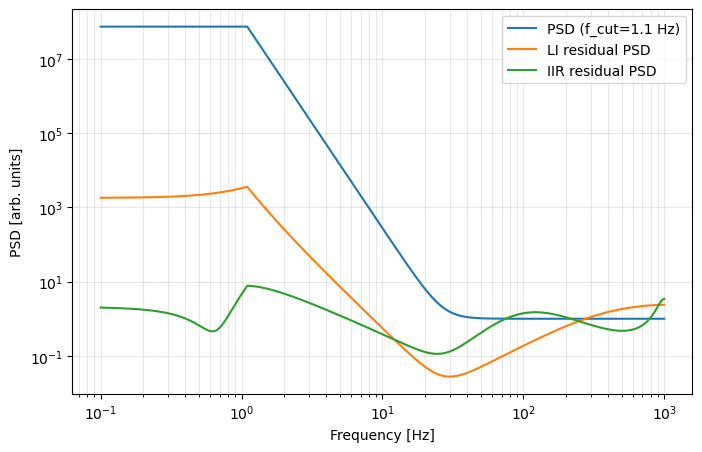

In [ ]:
init_res = psd / C_init
est_res = psd / C_est

plt.figure(figsize=(8,5))
plt.loglog(freq_psd, psd, label=f'PSD (f_cut={f_cut:.1f} Hz)')
plt.loglog(freq_psd, init_res, label='LI residual PSD')
plt.loglog(freq_psd, est_res, label='IIR residual PSD')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [arb. units]')
plt.grid(which='both', alpha=0.3)
plt.legend()

print(simps(init_res,freq_psd)/simps(est_res,freq_psd))

In [ ]:
n_vec = np.arange(1,36)

p_vec = np.zeros([len(n_vec),order])
z_vec = np.zeros([len(n_vec),order])

V = 10
noise_floor = 1e-8
theta_guess = None

for i,n in enumerate(n_vec):
    psd, f_cut = get_zernike_spectra(freq_psd, n=n, V=V, noise_floor=noise_floor)
    psd /= noise_floor**2
    _,theta_est = estimate_theta(psd,f_cut,theta_guess=theta_guess)
    if n > 1:
        theta_guess = theta_est.copy()
    p_vec[i,:] = theta_est[:order]
    z_vec[i,:] = theta_est[order:]

b_est = theta_est[: order]
a_est = theta_est[order:]

filt_est = IirFilterData(ordnum=[len(a_est)], ordden=[len(b_est)], num=[a_est], den=[b_est])
C_est = filt_est.RTF(mode=0, fs=fs, freq=freq_psd, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)**-2 #np.abs(1 + filt_est.frequency_response(num=a_est, den=b_est, fs=fs, freq=freq_psd)) ** 2

plt.figure(figsize=(8,5))
plt.loglog(freq_psd, psd, label=f'PSD')
plt.loglog(freq_psd, C_est, label=r'IIR $|RFT|^{-2}$')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [arb. units]')
plt.grid(which='both', alpha=0.3)
plt.legend()

estimated theta [-0.52224706  1.04414579 -0.52189943 -0.11971547  0.20036463 -0.08911003]
zeros:  [0.83683681+0.20988717j 0.83683681-0.20988717j] , poles:  [0.99966651+0.00111153j 0.99966651-0.00111153j] , gain:  0.2292314966723168
estimated theta [-0.50132336  1.00214229 -0.50082108  0.23428608 -0.45522619  0.23393756]
zeros:  [0.97151777+0.23380682j 0.97151777-0.23380682j] , poles:  [0.9994969+0.00201293j 0.9994969-0.00201293j] , gain:  -0.46733526065600856
estimated theta [-0.50146369  1.00218828 -0.50072843  0.2326408  -0.44749135  0.23004152]
zeros:  [0.96176454+0.25265791j 0.96176454-0.25265791j] , poles:  [0.99926307+0.0026651j 0.99926307-0.0026651j] , gain:  -0.46392353224693583
estimated theta [-0.50159566  1.00219741 -0.50060785  0.22732692 -0.43434664  0.22319194]
zeros:  [0.95533482+0.26295592j 0.95533482-0.26295592j] , poles:  [0.99900926+0.00334074j 0.99900926-0.00334074j] , gain:  -0.4532075123194051
estimated theta [-0.50172721  1.00218856 -0.50047031  0.22093154 -0.420

In [ ]:
plt.figure()
plt.plot(p_vec[1:,0]-p_vec[1,0])
plt.plot(p_vec[1:,1]-p_vec[1,1])
plt.plot(p_vec[1:,2]-p_vec[1,2])
plt.grid()

plt.figure()
plt.plot(z_vec[1:,0]-z_vec[1,0])
plt.plot(z_vec[1:,1]-z_vec[1,1])
plt.plot(z_vec[1:,2]-z_vec[1,2])
plt.grid()

NameError: name 'plt' is not defined

In [ ]:
from astropy.io import fits

fits.writeto(f'./calibration/filter/iir_poles_freq{fs:1.0f}Hz_delay{delay_frames:1.1f}fr.fits',p_vec)
fits.writeto(f'./calibration/filter/iir_zeros_freq{fs:1.0f}Hz_delay{delay_frames:1.1f}fr.fits',z_vec)

In [ ]:
# freqs = np.logspace(-2, np.log10(fs/2), 2000)
# psd, f_cut = get_zernike_spectra(freqs, n=1, V=40, r0=5e-2, L0=25, D=1.82)
# print(np.sqrt(simps(psd,freqs)))

# # plot results
# plt.figure(figsize=(8,5))
# plt.loglog(freqs, psd, label=f'PSD (f_cut={f_cut:.1f} Hz)')
# plt.xlabel('Frequency [Hz]')
# plt.ylabel(r'PSD $[m^2]$')
# plt.title('Atmospheric KL-mode PSD + white noise')
# plt.grid(which='both', alpha=0.3)

# controller = IirFilterData.from_gain_and_ff(gain=[0.5], ff=[0.9995])
# rtf = controller.RTF(mode=0, fs=fs, freq=freqs, dm=dm_plant, nw=nw_plant, dw=1.0, plot=False)
# res = psd*rtf**2

# dm_cmd = psd - res + 1e-20

# print(np.sqrt(simps(res,freqs)),np.sqrt(simps(psd,freqs))-np.sqrt(simps(res,freqs)))

# plt.loglog(freqs, res, label=f'INT rejection')
# plt.loglog(freqs, dm_cmd, '--')
# plt.legend()